In [16]:
# %% [markdown]
# # Checkpoint Validation & Generation Scanner
#
# This notebook scans the `commands/checkpoints/` directory.
# For every checkpoint found, it:
# 1. Infers the model configuration (Channels/Resolution) from the folder path.
# 2. Loads the DiT model.
# 3. Generates 5 synthetic images to verify the frozen core is working.

# %%
import sys
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Ensure 'src' is in the python path
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))
    print(f"✅ Added {PROJECT_ROOT}/src to path")
else:
    raise FileNotFoundError("Could not find 'src' directory. Run this notebook from the project root (andreamoleri-federatedfactory).")

# Import internal modules
try:
    from models.diffusion import DiT, DiffusionConfig, rectified_flow_sampler
    print("✅ Models imported successfully")
except ImportError as e:
    print(f"❌ Failed to import models: {e}")
    print("Ensure you have installed the requirements (EDM2 submodule dependencies).")

# %%
# ==========================================
# 2. CONFIGURATION & INFERENCE UTILITIES
# ==========================================

def infer_config_from_path(ckpt_path: Path):
    """
    Infers the DiT configuration based on the dataset name found in the file path.
    Matches logic from src/checkpoint_trainer.py and src/imports/data_management.py
    """
    path_str = str(ckpt_path).lower()

    # --- DEFAULTS ---
    embed_dim = 128
    dropout = 0.30
    num_classes = 0 # Checkpoints are usually class-specific (unconditional models)

    # --- 1. RESOLUTION & CHANNELS HEURISTICS ---

    # A. MedMNIST Logic (Usually 28x28)
    if "medmnist" in path_str:
        res = 28
        channel_mult = [1, 2, 2] # Specific to 28x28 in trainer script

        # Channel inference based on MedMNIST subsets
        # GrayScale: Organ, OCT, Pneumonia, Tissue, Breast
        if any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
            in_ch = 1
        # RGB: Path, Blood, Retina, Derma
        else:
            in_ch = 3

    # B. CIFAR Logic (32x32)
    elif "cifar" in path_str:
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # C. ISIC / Medical High Res (Assume 32 or 64 for testing baselines unless specified)
    elif "isic" in path_str:
        # Based on typical settings in this repo for lower compute
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # D. Default Fallback
    else:
        print(f"⚠️ Warning: Could not infer config for {ckpt_path.parent.name}, assuming 32x32 RGB")
        res = 32
        in_ch = 3
        channel_mult = [1, 2, 2, 2]

    # Create Config Object
    cfg = DiffusionConfig(
        in_ch=in_ch,
        embed_dim=embed_dim,
        channel_mult=channel_mult,
        dropout=dropout,
        img_resolution=res,
        num_classes=num_classes
    )

    return cfg

def show_images(tensors, title="Generated"):
    """
    Displays a row of tensors.
    Expects tensors in range [-1, 1] (DiT output)
    """
    # Denormalize [-1, 1] -> [0, 1]
    tensors = (tensors.detach().cpu() + 1) / 2.0
    tensors = tensors.clamp(0, 1)

    n = len(tensors)
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    if n == 1: axes = [axes]

    for i, ax in enumerate(axes):
        img = tensors[i].permute(1, 2, 0).numpy()
        # Handle Grayscale
        if img.shape[2] == 1:
            img = img.squeeze(2)
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.axis("off")

    fig.suptitle(title, fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

# %%
# ==========================================
# 3. SCANNER & GENERATOR (FINAL FIX)
# ==========================================

# %%
# ==========================================
# 3. SCANNER & GENERATOR (SMART CONFIG)
# ==========================================
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import re

# (Assumes DiT, DiffusionConfig, rectified_flow_sampler are imported)

def adjust_state_dict(ckpt_state_dict, model_state_dict):
    """
    Remaps checkpoint keys to match the model's expected structure.
    """
    new_state_dict = {}
    model_has_wrapper = any(k.startswith("edm_net.") for k in model_state_dict.keys())

    for k, v in ckpt_state_dict.items():
        if k in ["stds", "emas", "loss_fn", "optimizer", "state"]: continue

        clean_k = k.replace("module.", "").replace("_orig_mod.", "")

        # Smart Prefixing
        if model_has_wrapper and not clean_k.startswith("edm_net."):
            new_key = f"edm_net.{clean_k}"
        else:
            new_key = clean_k

        # Match against model keys (exact or cleanup)
        if new_key in model_state_dict:
            new_state_dict[new_key] = v
        elif clean_k in model_state_dict:
            new_state_dict[clean_k] = v

    return new_state_dict

def detect_config_from_weights(ckpt_path, raw_state_dict):
    """
    Inspects layer names in the weights to determine resolution and depth.
    """
    keys = list(raw_state_dict.keys())
    keys_str = " ".join(keys)

    # 1. Detect Channels (Grayscale vs RGB)
    # Heuristic: Check filename for specific medmnist subsets
    path_str = str(ckpt_path).lower()
    if any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
        in_ch = 1
    else:
        in_ch = 3

    # 2. Detect Resolution via layer names
    # Look for the presence of specific resolution blocks (e.g. "32x32_block", "28x28_block")
    if "32x32" in keys_str:
        res = 32
        channel_mult = [1, 2, 2, 2] # Standard for 32px
        print(f"   🕵️  Detected 32x32 architecture from weights.")
    elif "28x28" in keys_str:
        res = 28
        channel_mult = [1, 2, 2]    # Standard for 28px
        print(f"   🕵️  Detected 28x28 architecture from weights.")
    else:
        # Fallback to filename logic if keys are ambiguous
        if "medmnist" in path_str:
            res = 28
            channel_mult = [1, 2, 2]
        else:
            res = 32
            channel_mult = [1, 2, 2, 2]
        print(f"   🕵️  Architecture ambiguous, defaulting to {res}x{res}.")

    return DiffusionConfig(
        in_ch=in_ch,
        embed_dim=128,
        channel_mult=channel_mult,
        dropout=0.0,
        img_resolution=res,
        num_classes=0
    )

def scan_and_generate():
    possible_paths = [PROJECT_ROOT / "commands" / "checkpoints", PROJECT_ROOT / "checkpoints"]
    ckpt_root = next((p for p in possible_paths if p.exists()), None)

    if not ckpt_root: return

    checkpoints = sorted(list(ckpt_root.rglob("*.pt")))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using Device: {device}\n")

    for i, ckpt in enumerate(checkpoints):
        rel_path = ckpt.relative_to(ckpt_root)
        print(f"[{i+1}/{len(checkpoints)}] Processing: {rel_path}")

        try:
            # A. Load Raw Data FIRST to detect config
            chkpt_data = torch.load(ckpt, map_location=device)

            # Extract weights logic
            raw_state_dict = None
            if isinstance(chkpt_data, dict):
                if "net" in chkpt_data: raw_state_dict = chkpt_data["net"]
                elif "ema" in chkpt_data and len(chkpt_data["ema"]) > 10: raw_state_dict = chkpt_data["ema"]
                elif "state_dict" in chkpt_data: raw_state_dict = chkpt_data["state_dict"]
                elif "model" in chkpt_data: raw_state_dict = chkpt_data["model"]

            if raw_state_dict is None: raw_state_dict = chkpt_data

            # B. Detect Config from the extracted keys
            cfg = detect_config_from_weights(ckpt, raw_state_dict)

            # C. Initialize Model
            model = DiT(cfg).to(device)

            # D. Fix & Load Keys
            clean_state_dict = adjust_state_dict(raw_state_dict, model.state_dict())
            msg = model.load_state_dict(clean_state_dict, strict=False)

            # E. Report
            missing_weights = [k for k in msg.missing_keys if "weight" in k]
            if missing_weights:
                print(f"   ⚠️ Warning: Missing {len(missing_weights)} keys.")
            else:
                print("   ✅ Weights loaded successfully.")

            # F. Generate
            model.eval()
            with torch.no_grad():
                samples = rectified_flow_sampler(
                    model, n=5, shape=(cfg.in_ch, cfg.img_resolution, cfg.img_resolution), steps=20, device=device
                )

            show_images(samples, title=f"{rel_path.parent.name} ({cfg.img_resolution}px)")

            del model, samples
            if device.type == 'cuda': torch.cuda.empty_cache()

        except Exception as e:
            print(f"❌ Error: {e}")

if __name__ == "__main__":
    scan_and_generate()

# %%
# ==========================================
# 4. EXECUTE
# ==========================================
if __name__ == "__main__":
    scan_and_generate()

✅ Added /home/amoleri/PycharmProjects/FederatedFactory/src to path
✅ Models imported successfully
🚀 Using Device: cpu

[1/299] Processing: cifar/silos/client_0/class_0/training-state-0000503.pt
   🕵️  Detected 32x32 architecture from weights.
   ✅ Weights loaded successfully.


KeyboardInterrupt: 

✅ Added /home/amoleri/PycharmProjects/FederatedFactory/src to path
✅ Models imported successfully
🚀 Found 775 total files. Processing 19 unique latest checkpoints.
🚀 Using Device: cpu

--- [1/19] Processing Latest: cifar/silos/client_0/class_0/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


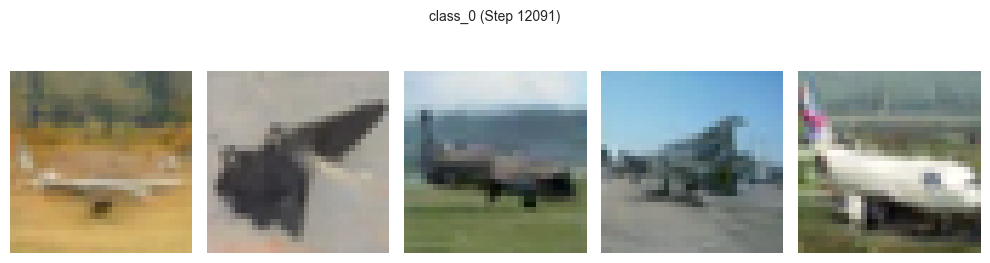

--- [2/19] Processing Latest: cifar/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


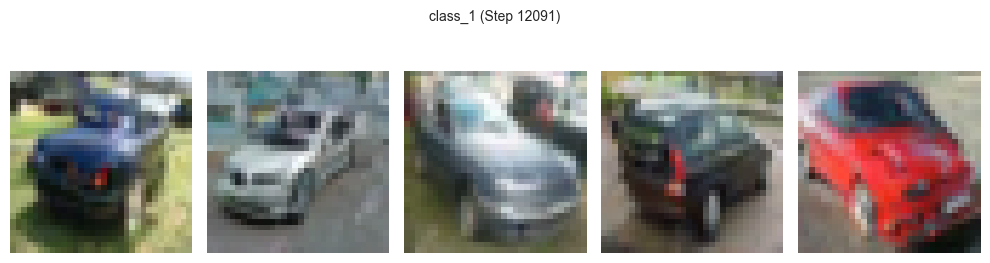

--- [3/19] Processing Latest: cifar/silos/client_2/class_2/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


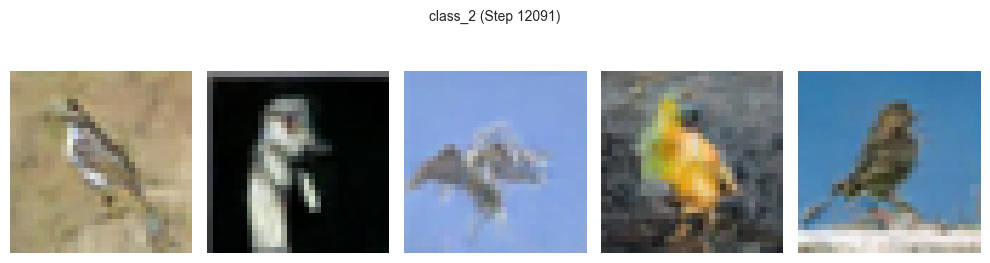

--- [4/19] Processing Latest: cifar/silos/client_3/class_3/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


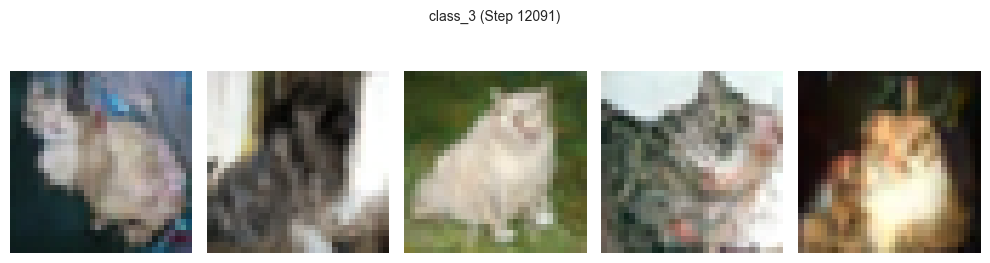

--- [5/19] Processing Latest: cifar/silos/client_4/class_4/training-state-0003022.pt ---
   🕵️  Detected 32x32 architecture from weights.


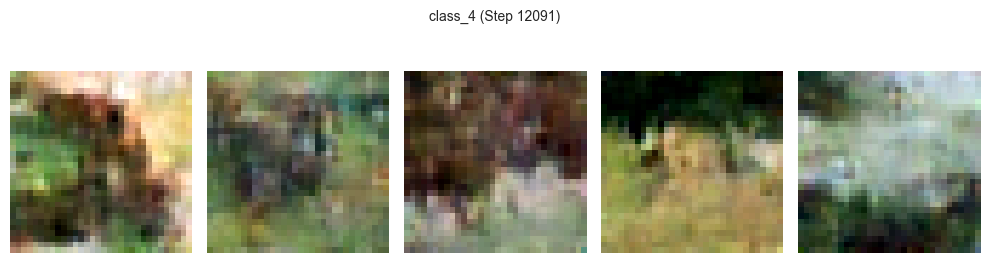

--- [6/19] Processing Latest: medmnist_bloodmnist/silos/client_0/class_0/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


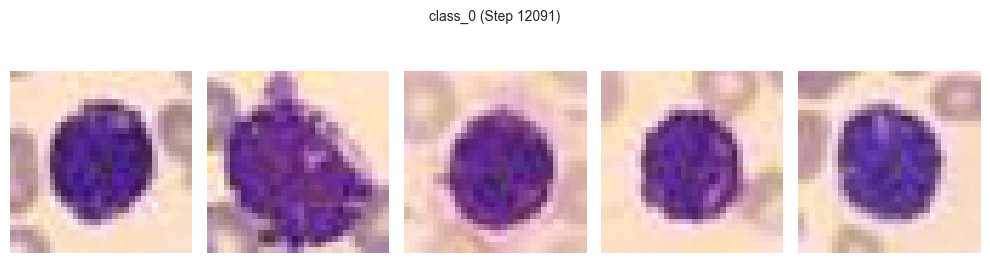

--- [7/19] Processing Latest: medmnist_bloodmnist/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


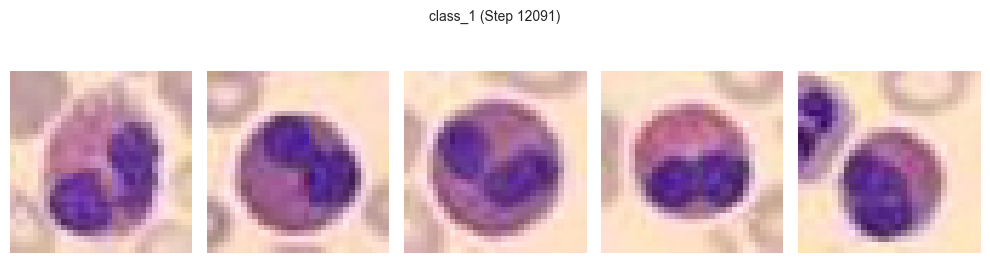

--- [8/19] Processing Latest: medmnist_bloodmnist/silos/client_2/class_2/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


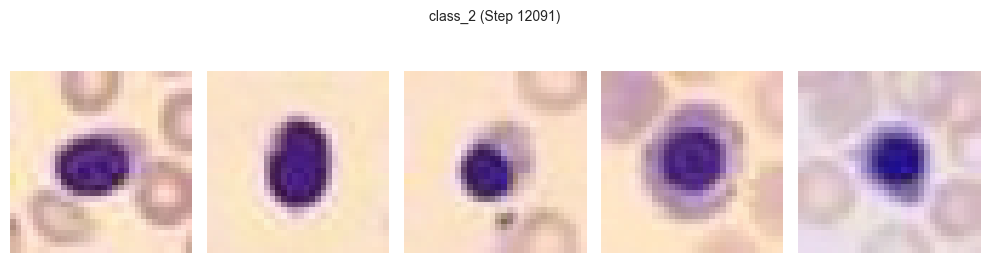

--- [9/19] Processing Latest: medmnist_bloodmnist/silos/client_3/class_3/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


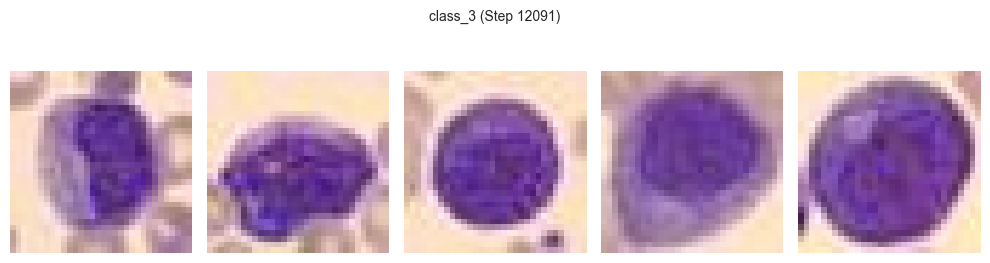

--- [10/19] Processing Latest: medmnist_bloodmnist/silos/client_4/class_4/training-state-0001502.pt ---
   🕵️  Detected 32x32 architecture from weights.


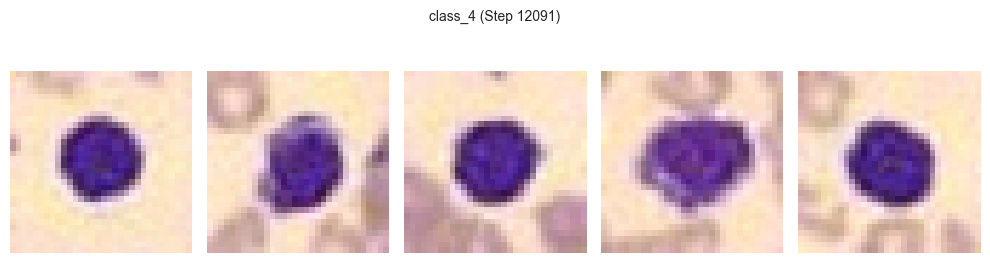

--- [11/19] Processing Latest: medmnist_pathmnist/silos/client_0/class_0/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


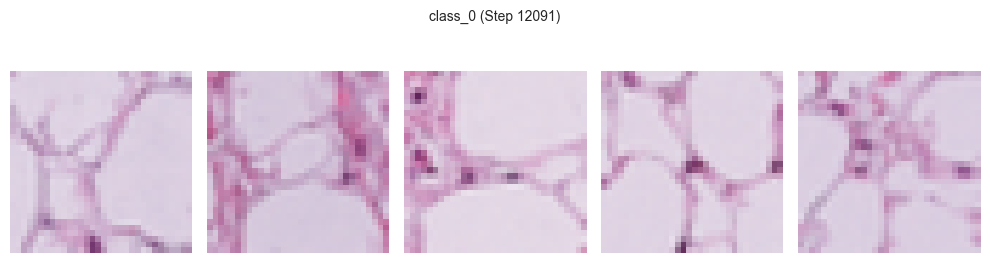

--- [12/19] Processing Latest: medmnist_pathmnist/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


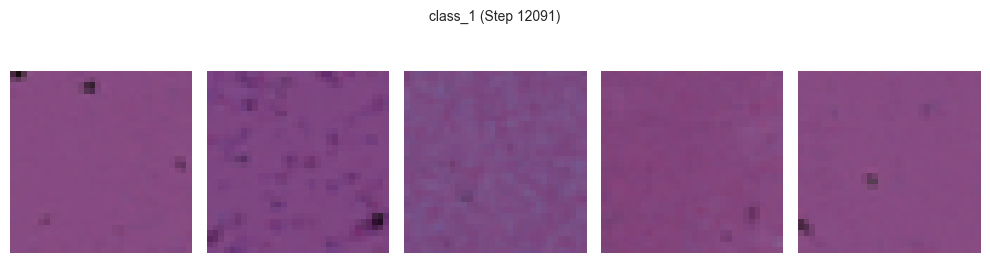

--- [13/19] Processing Latest: medmnist_pathmnist/silos/client_2/class_2/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


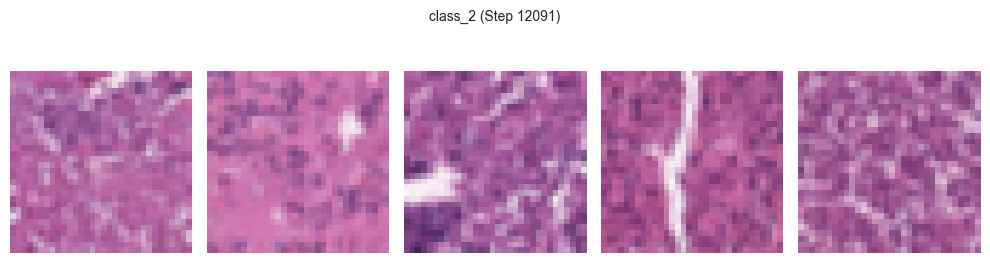

--- [14/19] Processing Latest: medmnist_pathmnist/silos/client_3/class_3/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


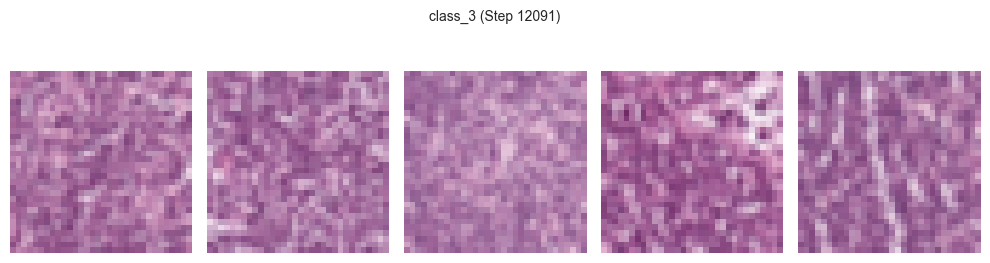

--- [15/19] Processing Latest: medmnist_pathmnist/silos/client_4/class_4/training-state-0002519.pt ---
   🕵️  Detected 32x32 architecture from weights.


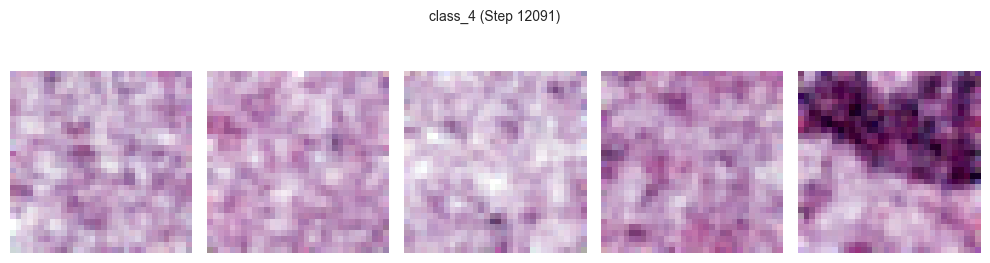

--- [16/19] Processing Latest: medmnist_retinamnist/silos/client_0/class_0/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


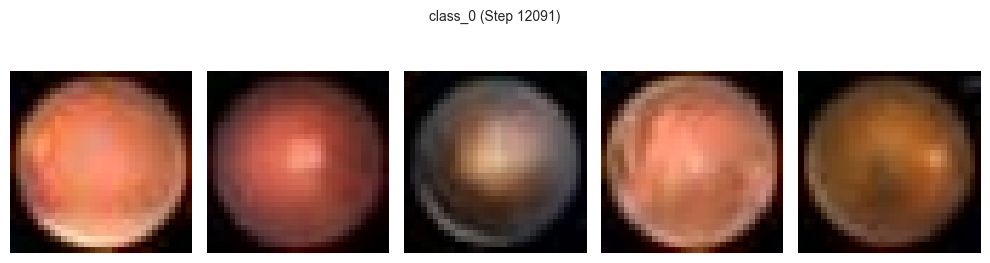

--- [17/19] Processing Latest: medmnist_retinamnist/silos/client_1/class_1/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


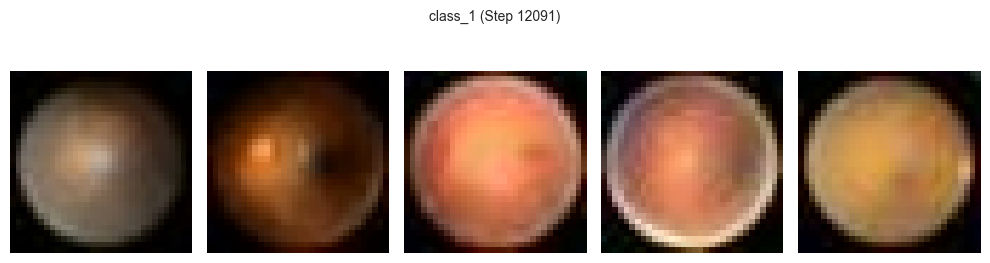

--- [18/19] Processing Latest: medmnist_retinamnist/silos/client_2/class_2/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


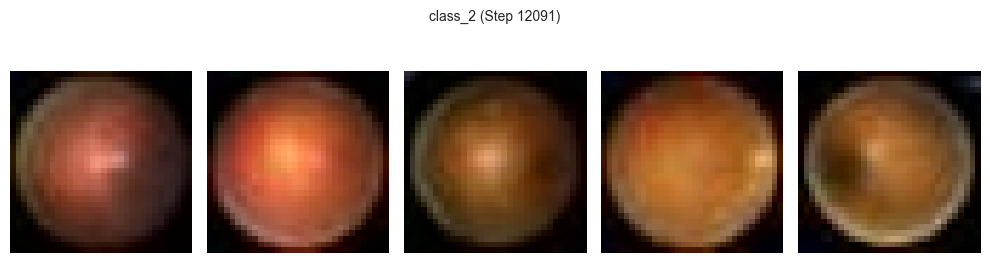

--- [19/19] Processing Latest: medmnist_retinamnist/silos/client_3/class_3/training-state-0005508.pt ---
   🕵️  Detected 32x32 architecture from weights.


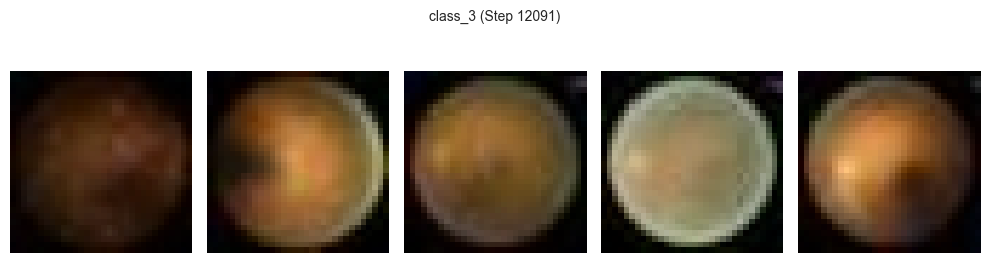

🚀 Found 775 total files. Processing 19 unique latest checkpoints.
🚀 Using Device: cpu

--- [1/19] Processing Latest: cifar/silos/client_0/class_0/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


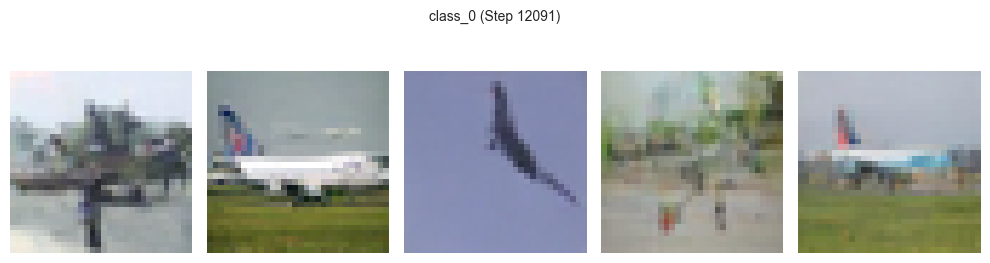

--- [2/19] Processing Latest: cifar/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


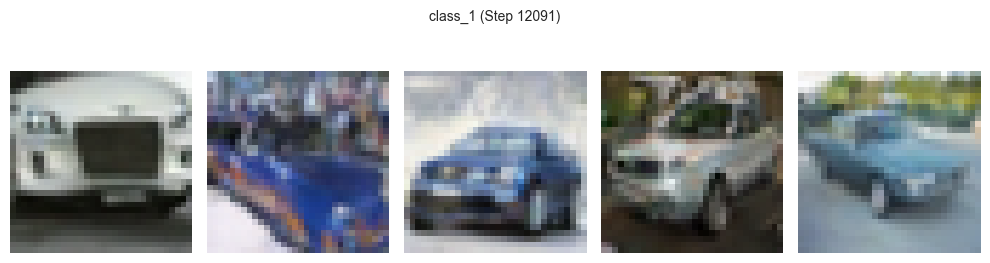

--- [3/19] Processing Latest: cifar/silos/client_2/class_2/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


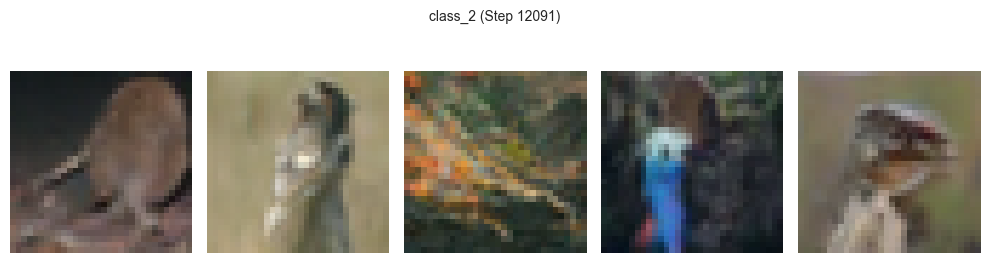

--- [4/19] Processing Latest: cifar/silos/client_3/class_3/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


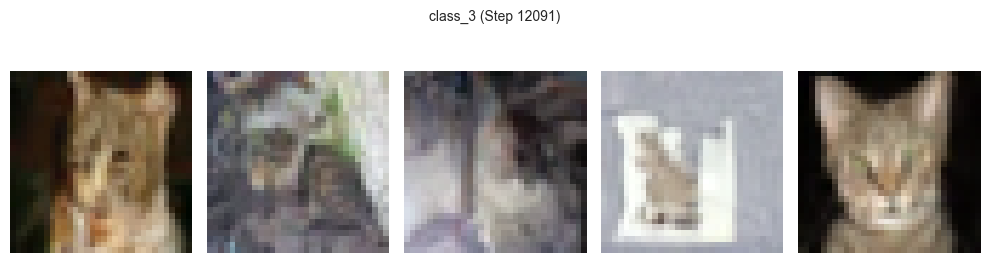

--- [5/19] Processing Latest: cifar/silos/client_4/class_4/training-state-0003022.pt ---
   🕵️  Detected 32x32 architecture from weights.


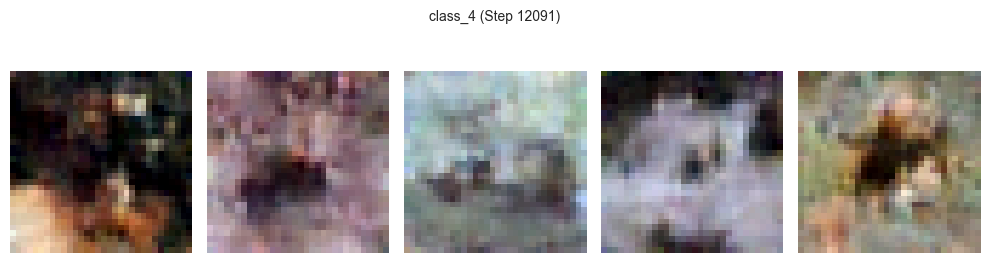

--- [6/19] Processing Latest: medmnist_bloodmnist/silos/client_0/class_0/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


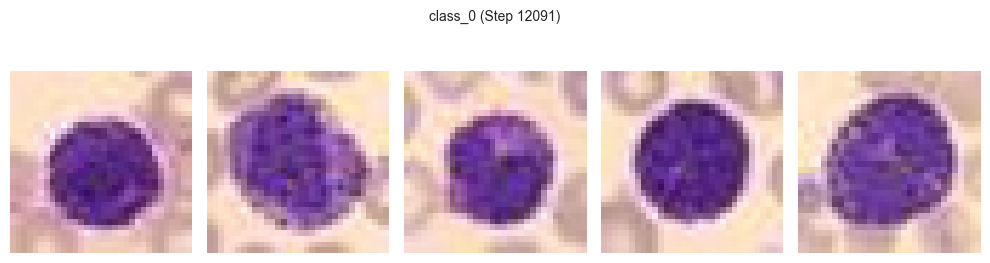

--- [7/19] Processing Latest: medmnist_bloodmnist/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


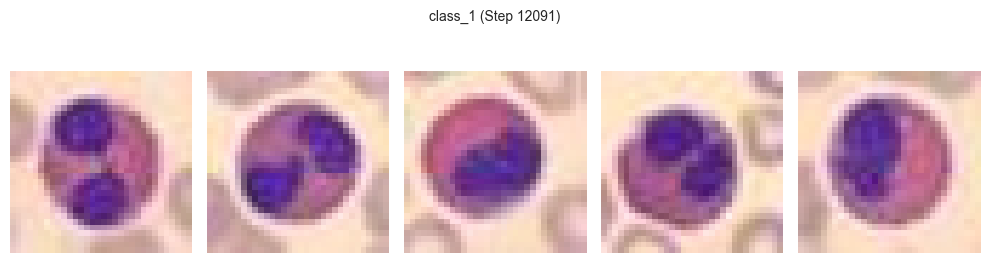

--- [8/19] Processing Latest: medmnist_bloodmnist/silos/client_2/class_2/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


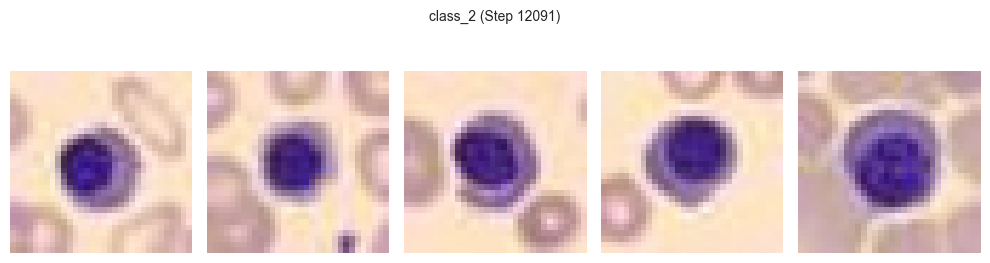

--- [9/19] Processing Latest: medmnist_bloodmnist/silos/client_3/class_3/training-state-0025000.pt ---
   🕵️  Detected 32x32 architecture from weights.


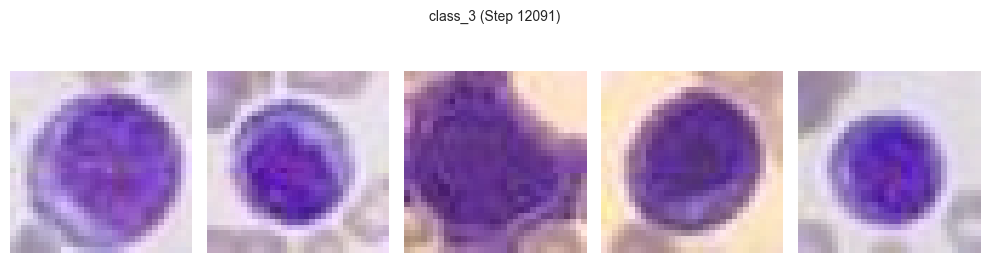

--- [10/19] Processing Latest: medmnist_bloodmnist/silos/client_4/class_4/training-state-0001502.pt ---
   🕵️  Detected 32x32 architecture from weights.


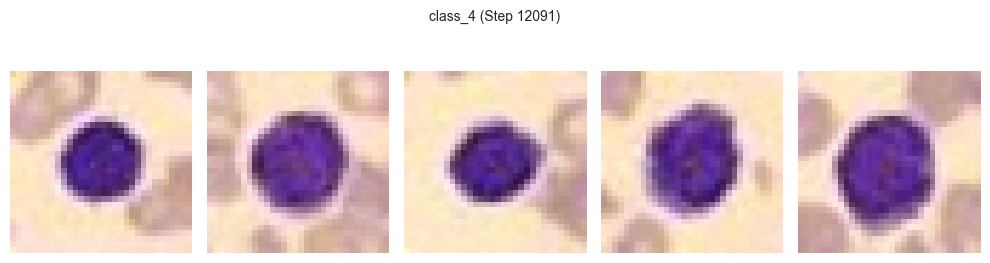

--- [11/19] Processing Latest: medmnist_pathmnist/silos/client_0/class_0/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


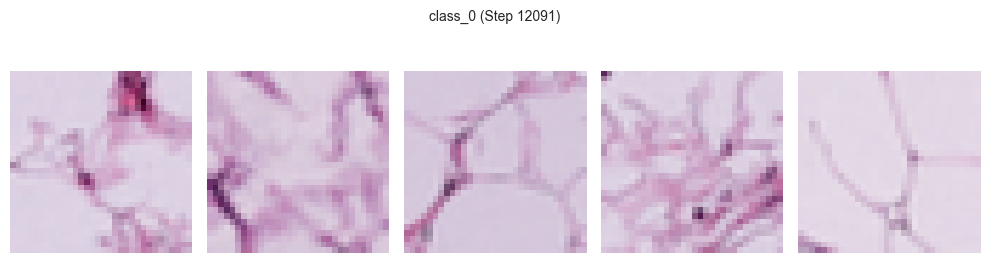

--- [12/19] Processing Latest: medmnist_pathmnist/silos/client_1/class_1/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


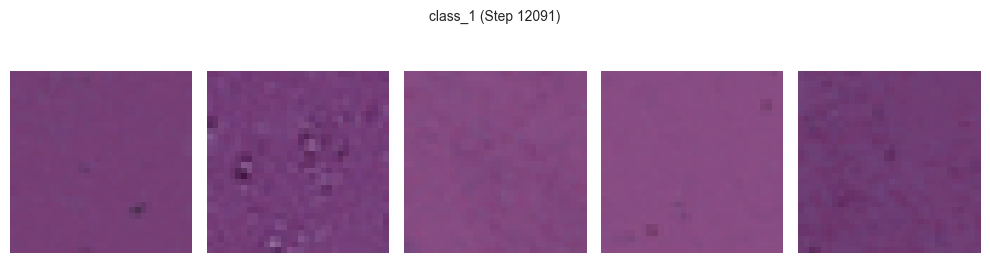

--- [13/19] Processing Latest: medmnist_pathmnist/silos/client_2/class_2/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


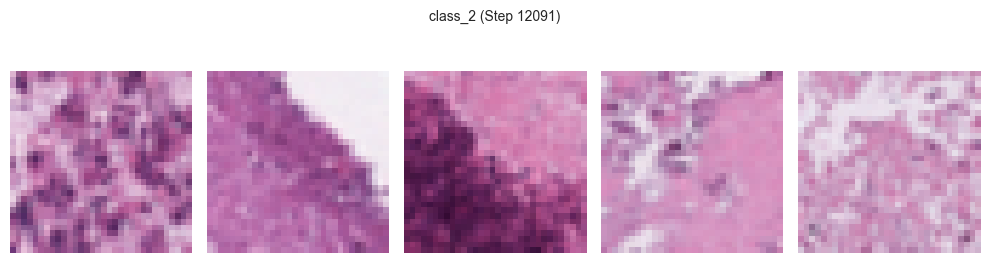

--- [14/19] Processing Latest: medmnist_pathmnist/silos/client_3/class_3/training-state-0025001.pt ---
   🕵️  Detected 32x32 architecture from weights.


KeyboardInterrupt: 

In [19]:
# %% [markdown]
# # Checkpoint Validation & Generation Scanner
#
# This notebook scans the `commands/checkpoints/` directory.
# For every checkpoint found, it:
# 1. Infers the model configuration (Channels/Resolution) from the folder path.
# 2. Loads the DiT model.
# 3. Generates 5 synthetic images to verify the frozen core is working.

# %%
import sys
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Ensure 'src' is in the python path
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))
    print(f"✅ Added {PROJECT_ROOT}/src to path")
else:
    raise FileNotFoundError("Could not find 'src' directory. Run this notebook from the project root (andreamoleri-federatedfactory).")

# Import internal modules
try:
    from models.diffusion import DiT, DiffusionConfig, rectified_flow_sampler
    print("✅ Models imported successfully")
except ImportError as e:
    print(f"❌ Failed to import models: {e}")
    print("Ensure you have installed the requirements (EDM2 submodule dependencies).")

# %%
# ==========================================
# 2. CONFIGURATION & INFERENCE UTILITIES
# ==========================================

def infer_config_from_path(ckpt_path: Path):
    """
    Infers the DiT configuration based on the dataset name found in the file path.
    Matches logic from src/checkpoint_trainer.py and src/imports/data_management.py
    """
    path_str = str(ckpt_path).lower()

    # --- DEFAULTS ---
    embed_dim = 128
    dropout = 0.30
    num_classes = 0 # Checkpoints are usually class-specific (unconditional models)

    # --- 1. RESOLUTION & CHANNELS HEURISTICS ---

    # A. MedMNIST Logic (Usually 28x28)
    if "medmnist" in path_str:
        res = 28
        channel_mult = [1, 2, 2] # Specific to 28x28 in trainer script

        # Channel inference based on MedMNIST subsets
        # GrayScale: Organ, OCT, Pneumonia, Tissue, Breast
        if any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
            in_ch = 1
        # RGB: Path, Blood, Retina, Derma
        else:
            in_ch = 3

    # B. CIFAR Logic (32x32)
    elif "cifar" in path_str:
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # C. ISIC / Medical High Res (Assume 32 or 64 for testing baselines unless specified)
    elif "isic" in path_str:
        # Based on typical settings in this repo for lower compute
        res = 32
        channel_mult = [1, 2, 2, 2]
        in_ch = 3

    # D. Default Fallback
    else:
        print(f"⚠️ Warning: Could not infer config for {ckpt_path.parent.name}, assuming 32x32 RGB")
        res = 32
        in_ch = 3
        channel_mult = [1, 2, 2, 2]

    # Create Config Object
    cfg = DiffusionConfig(
        in_ch=in_ch,
        embed_dim=embed_dim,
        channel_mult=channel_mult,
        dropout=dropout,
        img_resolution=res,
        num_classes=num_classes
    )

    return cfg

def show_images(tensors, title="Generated"):
    """
    Displays a row of tensors.
    Expects tensors in range [-1, 1] (DiT output)
    """
    # Denormalize [-1, 1] -> [0, 1]
    tensors = (tensors.detach().cpu() + 1) / 2.0
    tensors = tensors.clamp(0, 1)

    n = len(tensors)
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    if n == 1: axes = [axes]

    for i, ax in enumerate(axes):
        img = tensors[i].permute(1, 2, 0).numpy()
        # Handle Grayscale
        if img.shape[2] == 1:
            img = img.squeeze(2)
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.axis("off")

    fig.suptitle(title, fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

# %%
# ==========================================
# 3. SCANNER & GENERATOR (FINAL FIX)
# ==========================================

# %%
# ==========================================
# 3. SCANNER & GENERATOR (SMART CONFIG)
# ==========================================
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import re

# (Assumes DiT, DiffusionConfig, rectified_flow_sampler are imported)

def adjust_state_dict(ckpt_state_dict, model_state_dict):
    """
    Remaps checkpoint keys to match the model's expected structure.
    """
    new_state_dict = {}
    model_has_wrapper = any(k.startswith("edm_net.") for k in model_state_dict.keys())

    for k, v in ckpt_state_dict.items():
        if k in ["stds", "emas", "loss_fn", "optimizer", "state"]: continue

        clean_k = k.replace("module.", "").replace("_orig_mod.", "")

        # Smart Prefixing
        if model_has_wrapper and not clean_k.startswith("edm_net."):
            new_key = f"edm_net.{clean_k}"
        else:
            new_key = clean_k

        # Match against model keys (exact or cleanup)
        if new_key in model_state_dict:
            new_state_dict[new_key] = v
        elif clean_k in model_state_dict:
            new_state_dict[clean_k] = v

    return new_state_dict

def detect_config_from_weights(ckpt_path, raw_state_dict):
    """
    Inspects layer names in the weights to determine resolution and depth.
    """
    keys = list(raw_state_dict.keys())
    keys_str = " ".join(keys)

    # 1. Detect Channels (Grayscale vs RGB)
    # Heuristic: Check filename for specific medmnist subsets
    path_str = str(ckpt_path).lower()
    if any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
        in_ch = 1
    else:
        in_ch = 3

    # 2. Detect Resolution via layer names
    # Look for the presence of specific resolution blocks (e.g. "32x32_block", "28x28_block")
    if "32x32" in keys_str:
        res = 32
        channel_mult = [1, 2, 2, 2] # Standard for 32px
        print(f"   🕵️  Detected 32x32 architecture from weights.")
    elif "28x28" in keys_str:
        res = 28
        channel_mult = [1, 2, 2]    # Standard for 28px
        print(f"   🕵️  Detected 28x28 architecture from weights.")
    else:
        # Fallback to filename logic if keys are ambiguous
        if "medmnist" in path_str:
            res = 28
            channel_mult = [1, 2, 2]
        else:
            res = 32
            channel_mult = [1, 2, 2, 2]
        print(f"   🕵️  Architecture ambiguous, defaulting to {res}x{res}.")

    return DiffusionConfig(
        in_ch=in_ch,
        embed_dim=128,
        channel_mult=channel_mult,
        dropout=0.0,
        img_resolution=res,
        num_classes=0
    )

import re
from collections import defaultdict

def scan_and_generate():
    possible_paths = [PROJECT_ROOT / "commands" / "checkpoints", PROJECT_ROOT / "checkpoints"]
    ckpt_root = next((p for p in possible_paths if p.exists()), None)

    if not ckpt_root:
        print("❌ No checkpoint directory found.")
        return

    # 1. Find all .pt files
    all_checkpoints = list(ckpt_root.rglob("*.pt"))

    # 2. Group by folder and find the highest number
    # Key: Parent Directory Path, Value: Path to highest checkpoint
    latest_checkpoints = {}

    for ckpt in all_checkpoints:
        folder = ckpt.parent

        # Extract digits from filename (e.g., 'ckpt_150.pt' -> 150)
        # If no number is found, we treat it as 0
        match = re.search(r'(\d+)', ckpt.name)
        current_val = int(match.group(1)) if match else 0

        if folder not in latest_checkpoints:
            latest_checkpoints[folder] = ckpt
        else:
            # Compare current file number with the one already stored
            prev_ckpt = latest_checkpoints[folder]
            prev_match = re.search(r'(\d+)', prev_ckpt.name)
            prev_val = int(prev_match.group(1)) if prev_match else 0

            if current_val > prev_val:
                latest_checkpoints[folder] = ckpt

    # Convert dictionary values back to a sorted list
    checkpoints = sorted(list(latest_checkpoints.values()))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Found {len(all_checkpoints)} total files. Processing {len(checkpoints)} unique latest checkpoints.")
    print(f"🚀 Using Device: {device}\n")

    for i, ckpt in enumerate(checkpoints):
        rel_path = ckpt.relative_to(ckpt_root)
        print(f"--- [{i+1}/{len(checkpoints)}] Processing Latest: {rel_path} ---")

        try:
            # Load Data
            chkpt_data = torch.load(ckpt, map_location=device)

            # Weight extraction logic (same as your original code)
            raw_state_dict = None
            if isinstance(chkpt_data, dict):
                if "net" in chkpt_data: raw_state_dict = chkpt_data["net"]
                elif "ema" in chkpt_data and len(chkpt_data["ema"]) > 10: raw_state_dict = chkpt_data["ema"]
                elif "state_dict" in chkpt_data: raw_state_dict = chkpt_data["state_dict"]
                elif "model" in chkpt_data: raw_state_dict = chkpt_data["model"]
            if raw_state_dict is None: raw_state_dict = chkpt_data

            # Detect Config & Model Init
            cfg = detect_config_from_weights(ckpt, raw_state_dict)
            model = DiT(cfg).to(device)

            # Load & Generate
            clean_state_dict = adjust_state_dict(raw_state_dict, model.state_dict())
            model.load_state_dict(clean_state_dict, strict=False)

            model.eval()
            with torch.no_grad():
                samples = rectified_flow_sampler(
                    model, n=5, shape=(cfg.in_ch, cfg.img_resolution, cfg.img_resolution), steps=20, device=device
                )

            show_images(samples, title=f"{rel_path.parent.name} (Step {current_val})")

            del model, samples
            if device.type == 'cuda': torch.cuda.empty_cache()

        except Exception as e:
            print(f"❌ Error processing {ckpt.name}: {e}")

if __name__ == "__main__":
    scan_and_generate()

# %%
# ==========================================
# 4. EXECUTE
# ==========================================
if __name__ == "__main__":
    scan_and_generate()